In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
def imshow(image= None):
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

In [40]:
def k_mean(image, contour):

  # create mask and pixels
  mask = np.zeros(image.shape[:2], np.uint8)
  cv.drawContours(mask, [contour], -1, 255, -1)
  pixels = image[mask == 255]

  # K-menas
  pixels = np.float32(pixels)
  criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
  k = 3
  if len(pixels) < k:
    return "No Color"
  if len(pixels) == 0:
    return "No Color"
  ret, labels, centers = cv.kmeans(pixels, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
  centers = np.uint8(centers)
  labels = labels.flatten()
  count = np.bincount(labels)
  precenate = count / count.sum()
  idx = np.argsort(precenate)[::-1]
  centers = centers[idx]
  precenate = precenate[idx]
  dominated_color = centers[0]

  # set color
  B, G, R = dominated_color
  color = "Unknown"
  if B > G and B > R:
    color = "Blue"
  elif G > B and G > R:
    color = "Green"
  elif R > B and R > G:
    color = "Red"

  return color


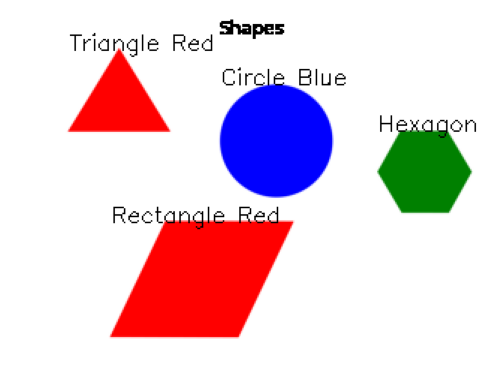

In [41]:
image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/shapes.png")
# convert to gray scale
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

# find contour
ret, threshold = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
contours, hierarchy = cv.findContours(threshold, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
# detected shpe
shape = ""
color = ""
for cnt in contours:

    if cv.contourArea(cnt) < 100:
        continue
    approx = cv.approxPolyDP(
        cnt,
        0.03 * cv.arcLength(cnt, True),
        True
    )
    color = k_mean(image, cnt)
    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        shape = "Rectangle"
    elif len(approx) == 5:
        shape = "Pentagon"
    elif len(approx) == 6:
      shape = "Hexagon"
    elif len(approx) >= 7:
        shape = "Circle"
    else:
        shape = "Unknown"

    x, y, w, h = cv.boundingRect(cnt)
    cv.putText(
        image,
        f"{shape} {color}",
        (x, y),
        cv.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 0, 0),
        1
    )

imshow(image= image)

